# Notebook 1 — Foundations (Build & Break)
### Gradient Autopsy · Phase 1

This notebook builds the fragile network and reproduces its failures: MLP vs CNN, cross-entropy vs
MSE, the vanishing-gradient heatmap, and overfitting. All shared infrastructure is loaded from
`common.py`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive"   # common.py reads this to know where to save results

Mounted at /content/drive


In [3]:
import shutil
shutil.copytree("/content/drive/MyDrive/cifar_data/data", "./data", dirs_exist_ok=True)
print("CIFAR restored from Drive — no re-download needed ✓")

CIFAR restored from Drive — no re-download needed ✓


In [4]:
%run /content/drive/MyDrive/gradient_autopsy_common.py

[common] Loaded: CONFIG, set_seed, device, loaders, FragileCNN, train_and_instrument, plot_gradient_heatmap, MLP, SmallCNN, train_timed
[common] device=cuda  RESULTS_DIR=./gradient_autopsy_results


In [5]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [6]:
import shutil, os
# Copy the downloaded CIFAR-10 from the temporary ./data into your Drive
os.makedirs("/content/drive/MyDrive/cifar_data", exist_ok=True)
shutil.copytree("./data", "/content/drive/MyDrive/cifar_data/data", dirs_exist_ok=True)
print("CIFAR-10 backed up to Drive ✓")

CIFAR-10 backed up to Drive ✓


## C5 · MLP vs CNN — why fully-connected is wrong for images

We compare a fully-connected MLP against a small CNN on CIFAR-10 at unequal parameter counts, and
report parameters, test accuracy, and training time. Expected (Card 4): the CNN wins on accuracy
*despite* having far fewer parameters — convolution exploits image structure while the MLP flattens
it away. Same seed / data / epochs, so architecture is the only difference.

In [7]:
# MLP, SmallCNN, count_params, train_timed all come from common.py — we just run the experiment.
EPOCHS = CONFIG["sweep_epochs"]

set_seed(CONFIG["seed"]); mlp = MLP(hidden=128)
set_seed(CONFIG["seed"]); cnn = SmallCNN(width=64)
print(f"MLP params: {count_params(mlp):,}   CNN params: {count_params(cnn):,}")
print("(CNN is far smaller but should win on accuracy.)\n")

print("Training MLP:")
set_seed(CONFIG["seed"])
mlp_acc, mlp_time, mlp_params = train_timed(MLP(hidden=128), full_train_loader, EPOCHS, verbose=True)

print("\nTraining CNN:")
set_seed(CONFIG["seed"])
cnn_acc, cnn_time, cnn_params = train_timed(SmallCNN(width=64), full_train_loader, EPOCHS, verbose=True)

print(f"\n{'Model':<8}{'Params':>12}{'Test Acc':>12}{'Time (s)':>12}")
print("-" * 44)
print(f"{'MLP':<8}{mlp_params:>12,}{mlp_acc:>12.3f}{mlp_time:>12.1f}")
print(f"{'CNN':<8}{cnn_params:>12,}{cnn_acc:>12.3f}{cnn_time:>12.1f}")

MLP params: 411,146   CNN params: 76,298
(CNN is far smaller but should win on accuracy.)

Training MLP:
  epoch 1/6: train_loss 1.655 | train_acc 0.415 | test_acc 0.453
  epoch 2/6: train_loss 1.455 | train_acc 0.486 | test_acc 0.499
  epoch 3/6: train_loss 1.363 | train_acc 0.519 | test_acc 0.498
  epoch 4/6: train_loss 1.290 | train_acc 0.543 | test_acc 0.505
  epoch 5/6: train_loss 1.231 | train_acc 0.565 | test_acc 0.510
  epoch 6/6: train_loss 1.175 | train_acc 0.583 | test_acc 0.510

Training CNN:
  epoch 1/6: train_loss 1.652 | train_acc 0.394 | test_acc 0.504
  epoch 2/6: train_loss 1.290 | train_acc 0.541 | test_acc 0.584
  epoch 3/6: train_loss 1.140 | train_acc 0.597 | test_acc 0.613
  epoch 4/6: train_loss 1.050 | train_acc 0.628 | test_acc 0.630
  epoch 5/6: train_loss 0.985 | train_acc 0.653 | test_acc 0.651
  epoch 6/6: train_loss 0.931 | train_acc 0.675 | test_acc 0.658

Model         Params    Test Acc    Time (s)
--------------------------------------------
MLP      

## C6 · Why Cross-Entropy, Not MSE, for Classification

Group 1 (Card 2) claimed cross-entropy is the right loss for classification and that MSE gives
"weak/flat gradients." Here we prove it with a number.

**The setup.** Same network, same seed, trained for one epoch two ways:
- **Cross-entropy** on raw logits (the standard choice).
- **MSE** applied to softmax probabilities vs a one-hot target (forcing MSE onto classification).

We measure the **first-layer gradient norm in epoch 1** — early training is where the difference is
sharpest, because that's when the model is still confidently wrong. If MSE really produces a weaker
learning signal, its gradient will be much smaller than cross-entropy's.

**Why it matters.** A loss function isn't just a scorecard — it *shapes the gradients* that drive
learning. A loss that produces tiny gradients when the model is confidently wrong trains slowly and
poorly, even with a perfectly good architecture.

Epoch-1 mean first-layer gradient norm:
  Cross-Entropy : 2.63652
  MSE           : 0.08784

Cross-entropy's gradient is ~30.0x larger than MSE's.
=> MSE gives a much weaker learning signal on classification (Card 2).


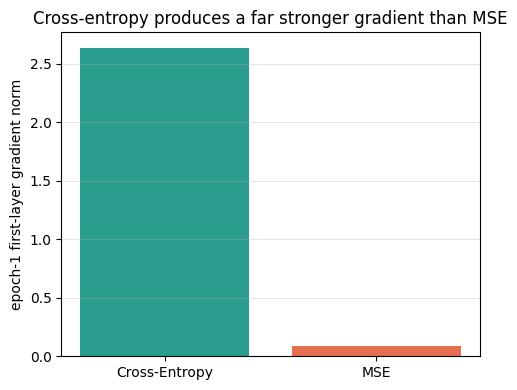

In [8]:
def measure_first_epoch_grad(loss_kind, seed=0, lr=0.1):
    """Train one epoch with the given loss; return the mean first-layer gradient norm.
    loss_kind: 'ce' (cross-entropy on logits) or 'mse' (MSE on softmax vs one-hot)."""
    set_seed(seed)
    # A simple, healthy net — we're isolating the LOSS effect, not architecture.
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(3 * 32 * 32, 128), nn.ReLU(),
        nn.Linear(128, 10),
    ).to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    ce_loss = nn.CrossEntropyLoss()
    mse_loss = nn.MSELoss()

    first_layer = model[1]           # the first Linear layer — the one we monitor
    grad_norms = []

    model.train()
    for X, y in full_train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)

        if loss_kind == "ce":
            # Cross-entropy operates on raw logits (applies softmax internally).
            loss = ce_loss(logits, y)
        else:
            # MSE forced onto classification: softmax PROBS vs a ONE-HOT target.
            probs = torch.softmax(logits, dim=1)
            onehot = torch.zeros_like(probs)
            onehot[range(len(y)), y] = 1.0
            loss = mse_loss(probs, onehot)

        loss.backward()
        # Record first layer's grad norm (after backward, before step).
        grad_norms.append(first_layer.weight.grad.norm().item())
        optimizer.step()

    return float(np.mean(grad_norms))


# --- Run both and compare ---
ce_grad  = measure_first_epoch_grad("ce")
mse_grad = measure_first_epoch_grad("mse")

print(f"Epoch-1 mean first-layer gradient norm:")
print(f"  Cross-Entropy : {ce_grad:.5f}")
print(f"  MSE           : {mse_grad:.5f}")
print(f"\nCross-entropy's gradient is ~{ce_grad / mse_grad:.1f}x larger than MSE's.")
print("=> MSE gives a much weaker learning signal on classification (Card 2).")

# --- Bar chart ---
plt.figure(figsize=(5, 4))
plt.bar(["Cross-Entropy", "MSE"], [ce_grad, mse_grad], color=["#2a9d8f", "#e76f51"])
plt.ylabel("epoch-1 first-layer gradient norm")
plt.title("Cross-entropy produces a far stronger gradient than MSE")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/c6_ce_vs_mse.png", dpi=120)
plt.show()

## C7 · The Vanishing Gradient — the "broken" heatmap

This is the centerpiece of Phase 1. We take the **fully fragile network** — 8 layers deep, sigmoid
activations, default init, no BatchNorm — and train it while logging the gradient norm of every layer
each epoch. Then we render the **layer × epoch heatmap**.

**What to expect:** the early layers (top of the heatmap, nearest the input) will be near-black —
their gradients are orders of magnitude smaller than the output layers'. The learning signal dies
before it reaches them. This is the vanishing gradient, seen directly.

We **save this heatmap's data to Drive** (`broken_grad_history.npy`) so the final synthesis notebook
can place it beside the "fixed" heatmap from Phase 2 — on identical axes — to show the cure.

This is the failure we deliberately leave unfixed here; Phase 2 (Notebook 2) is where we heal it.

Training the fragile network (watch the loss barely move — early layers are dead):
  epoch 1/6: train_loss 2.311 | train_acc 0.102 | test_acc 0.100
  epoch 2/6: train_loss 2.306 | train_acc 0.103 | test_acc 0.100
  epoch 3/6: train_loss 2.306 | train_acc 0.102 | test_acc 0.100
  epoch 4/6: train_loss 2.306 | train_acc 0.107 | test_acc 0.100
  epoch 5/6: train_loss 2.305 | train_acc 0.100 | test_acc 0.100
  epoch 6/6: train_loss 2.305 | train_acc 0.096 | test_acc 0.100

Saved broken heatmap data to ./gradient_autopsy_results/broken_grad_history.npy

First-layer vs last-layer gradient norm (the vanishing gradient):
  epoch 1: first=4.38e-08 | last=3.62e-01 | last is 8,275,454x larger
  epoch 2: first=4.39e-08 | last=3.18e-01 | last is 7,244,584x larger
  epoch 3: first=4.37e-08 | last=3.23e-01 | last is 7,381,886x larger
  epoch 4: first=4.40e-08 | last=3.19e-01 | last is 7,231,710x larger
  epoch 5: first=4.30e-08 | last=3.14e-01 | last is 7,309,682x larger
  epoch 6: first=4.36e-08 | l

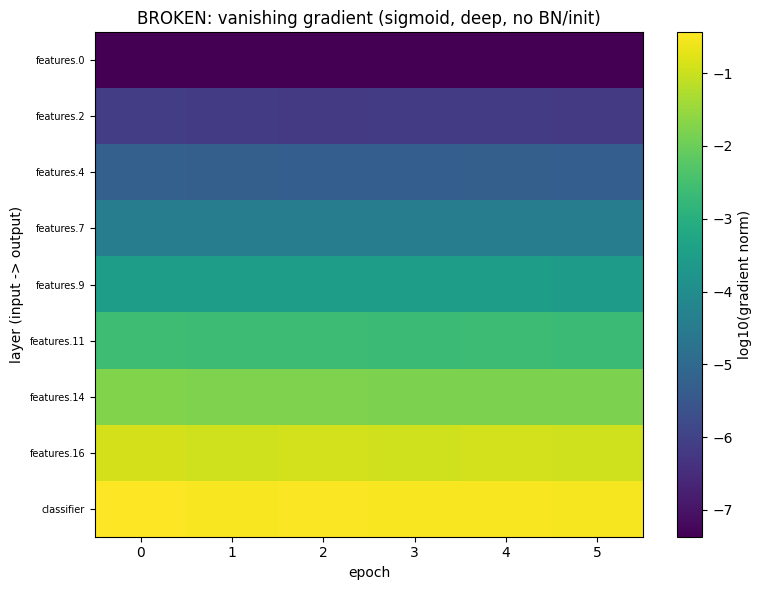

In [9]:
# Build the FULLY fragile network: deep, sigmoid, default init, no BatchNorm.
# This is the default FragileCNN config — every safeguard is deliberately OFF.
set_seed(CONFIG["seed"])
broken_model = FragileCNN(
    depth=CONFIG["cnn_depth"],       # 8 layers — deep enough to vanish
    width=CONFIG["cnn_width"],
    activation="sigmoid",            # saturating activation (the main culprit)
    use_bn=False,                    # no batch norm
    init="default",                  # no principled init
)

# Train it, logging per-layer gradient norms every epoch (this is C4's instrumented loop).
print("Training the fragile network (watch the loss barely move — early layers are dead):")
broken_result = train_and_instrument(
    broken_model,
    small_train_loader,              # small set is fine; we're studying gradients, not accuracy
    test_loader,
    epochs=CONFIG["sweep_epochs"],
    lr=0.1,
    verbose=True,
)

# --- Save the gradient history to Drive for the final synthesis notebook ---
np.save(f"{RESULTS_DIR}/broken_grad_history.npy", broken_result["grad_history"])
# Also save the layer names so the axes match exactly later.
np.save(f"{RESULTS_DIR}/broken_layer_names.npy", np.array(broken_result["layer_names"]))
print(f"\nSaved broken heatmap data to {RESULTS_DIR}/broken_grad_history.npy")

# --- Print the smoking gun: first vs last layer gradient each epoch ---
gh = broken_result["grad_history"]
print("\nFirst-layer vs last-layer gradient norm (the vanishing gradient):")
for ep in range(gh.shape[0]):
    ratio = gh[ep, -1] / (gh[ep, 0] + 1e-12)
    print(f"  epoch {ep+1}: first={gh[ep,0]:.2e} | last={gh[ep,-1]:.2e} | last is {ratio:,.0f}x larger")

# --- The heatmap (the deliverable) ---
plot_gradient_heatmap(broken_result, title="BROKEN: vanishing gradient (sigmoid, deep, no BN/init)")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/c7_broken_heatmap.png", dpi=120)
plt.show()

## C8 · Overfitting — the second failure

The vanishing gradient (C7) was a *training* failure. Overfitting is a *generalization* failure, and
it's the second problem Phase 1 exposes.

**The setup.** We take a **capable, healthy CNN** (ReLU — it *can* learn) and train it on the **fixed
4,000-image subset**. Small data + a capable model is the classic recipe for overfitting: the model
has enough capacity to *memorize* the small training set but too little data to learn patterns that
generalize.

**What to expect.** Train accuracy climbs high while test accuracy lags — the **gap** between them is
overfitting made visible. We train longer here (more epochs) because overfitting develops over time.

We save the train/test curves to Drive so the synthesis notebook can show how Phase 2's regularization
tools (dropout, weight decay, augmentation) shrink this gap.

This is the failure we deliberately leave unfixed here; Notebook 3 is where we cure it.

Training a capable CNN on only 4,000 images (watch the gap open):
  epoch  5/25: train_acc 0.428 | test_acc 0.408 | gap +0.020
  epoch 10/25: train_acc 0.507 | test_acc 0.456 | gap +0.051
  epoch 15/25: train_acc 0.532 | test_acc 0.472 | gap +0.060
  epoch 20/25: train_acc 0.628 | test_acc 0.530 | gap +0.098
  epoch 25/25: train_acc 0.652 | test_acc 0.543 | gap +0.108

Final train/test gap: +0.108  (this is the overfitting we'll cure in Phase 2)


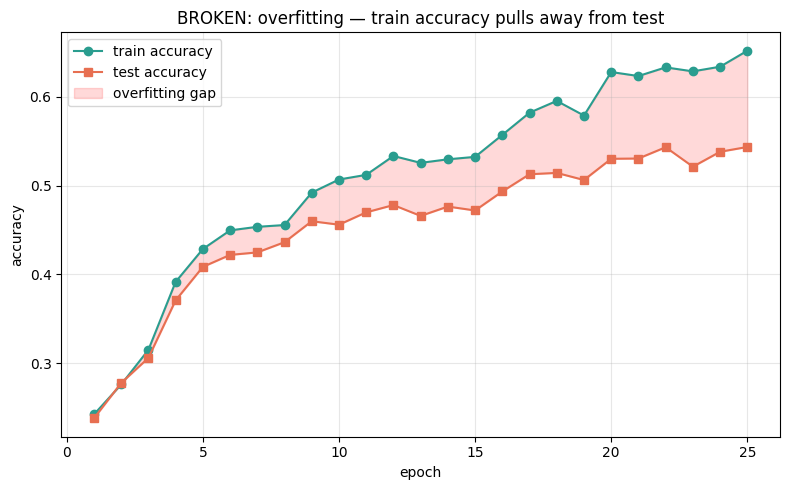

In [10]:
def train_track_gap(model, train_loader, test_loader, epochs=25, lr=1e-3, log_every=5):
    """Train and record train/test accuracy each epoch to expose overfitting.
    Prints every `log_every` epochs (and always the last)."""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    hist = {"train_acc": [], "test_acc": []}
    for ep in range(epochs):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
        # measure train and test accuracy this epoch
        _, tr = evaluate(model, train_loader)
        _, te = evaluate(model, test_loader)
        hist["train_acc"].append(tr)
        hist["test_acc"].append(te)
        # our logging rule: every `log_every` epochs, plus always the final one
        if (ep + 1) % log_every == 0 or ep == epochs - 1:
            print(f"  epoch {ep+1:>2}/{epochs}: train_acc {tr:.3f} | test_acc {te:.3f} | gap {tr-te:+.3f}")
    return hist


# Train a CAPABLE CNN on the SMALL subset -> overfitting.
print("Training a capable CNN on only 4,000 images (watch the gap open):")
set_seed(CONFIG["seed"])
overfit_model = SmallCNN(width=64)
overfit_hist = train_track_gap(
    overfit_model,
    small_train_loader,          # the fixed 4,000-image subset
    test_loader,
    epochs=25,                   # longer, so overfitting has time to develop
    lr=1e-3,
    log_every=5,
)

# --- Save for the synthesis notebook ---
np.save(f"{RESULTS_DIR}/overfit_train_acc.npy", np.array(overfit_hist["train_acc"]))
np.save(f"{RESULTS_DIR}/overfit_test_acc.npy",  np.array(overfit_hist["test_acc"]))
final_gap = overfit_hist["train_acc"][-1] - overfit_hist["test_acc"][-1]
print(f"\nFinal train/test gap: {final_gap:+.3f}  (this is the overfitting we'll cure in Phase 2)")

# --- Plot the two curves with the gap shaded ---
epochs_range = range(1, len(overfit_hist["train_acc"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, overfit_hist["train_acc"], "o-", label="train accuracy", color="#2a9d8f")
plt.plot(epochs_range, overfit_hist["test_acc"],  "s-", label="test accuracy",  color="#e76f51")
plt.fill_between(epochs_range, overfit_hist["train_acc"], overfit_hist["test_acc"],
                 alpha=0.15, color="red", label="overfitting gap")
plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.title("BROKEN: overfitting — train accuracy pulls away from test")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/c8_overfitting.png", dpi=120)
plt.show()